In [1]:
import clean_df
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\LT-MSI\.conda\envs\ADD\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = clean_df.clean()

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113121 entries, 730 to 3266950
Data columns (total 36 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        113121 non-null  object 
 1   Release date                113121 non-null  object 
 2   Estimated owners            113121 non-null  object 
 3   Peak CCU                    113121 non-null  int64  
 4   Required age                113121 non-null  int64  
 5   Price                       113121 non-null  float64
 6   Discount                    113121 non-null  int64  
 7   DLC count                   113121 non-null  int64  
 8   Supported languages         113121 non-null  object 
 9   Full audio languages        113121 non-null  object 
 10  Reviews                     113121 non-null  int64  
 11  Windows                     113121 non-null  bool   
 12  Mac                         113121 non-null  bool   
 13  Linux           

In [4]:
data.describe()

,Peak CCU,Required age,Price,Discount,DLC count,Reviews,Metacritic score,User score,Positive,Score rank,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,has_header image,has_screenshots,has_website,has_support url,has_support email,has_about the game,Ratio positive vote
count,1.131210e+05,113121.000000,113121.000000,113121.000000,113121.000000,113121.000000,113121.000000,113121.000000,1.131210e+05,40.000000,...,113121.000000,1.131210e+05,113121.000000,113121.000000,113121.000000,113121.000000,113121.000000,113121.000000,113121.000000,82037.000000
mean,5.886970e+01,0.174318,5.041820,19.738545,0.554415,0.265972,2.730925,0.026609,1.107718e+03,99.175000,...,14.797314,1.806474e+02,15.811812,0.999505,0.999470,0.432669,0.471363,0.879085,0.998471,0.758784
std,3.882519e+03,1.684912,12.760783,29.477639,14.361501,0.911446,14.071254,1.452215,2.917317e+04,0.675107,...,281.081865,1.163711e+04,306.237297,0.022244,0.023025,0.495448,0.499181,0.326030,0.039077,0.238371
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,98.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000e+00,0.000000,0.890000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,99.000000,...,0.000000,0.000000e+00,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.650000
50%,0.000000e+00,0.000000,2.740000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000e+00,99.000000,...,0.000000,0.000000e+00,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.818792
75%,0.000000e+00,0.000000,5.990000,50.000000,0.000000,0.000000,0.000000,0.000000,4.400000e+01,100.000000,...,0.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.944444
max,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,14.000000,97.000000,100.000000,7.642084e+06,100.000000,...,20088.000000,3.429544e+06,20088.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
np.shape(data)

(113121, 36)

In [6]:
list_cols = ["Genres", "Tags", "Supported languages", "Publishers", "Developers", "Full audio languages", "Categories"]
cols = [c for c in data.columns if c not in list_cols]
n_duplicated = data[cols].duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

df = pd.DataFrame({
    'n_unique':data[cols].nunique(),
    'n_missing':data[cols].isna().sum(),
    'missing_ratio':data[cols].isna().mean(),
    'dtype':data[cols].dtypes.values
})

display(
    df.style.background_gradient(cmap='BuPu')
        .format({"missing_ratio": "{:.2%}"})
)

Number of duplicated rows: 0



,n_unique,n_missing,missing_ratio,dtype
Name,112121,0,0.00%,object
Release date,5075,0,0.00%,object
Estimated owners,14,0,0.00%,object
Peak CCU,1105,0,0.00%,int64
Required age,15,0,0.00%,int64
Price,918,0,0.00%,float64
Discount,88,0,0.00%,int64
DLC count,116,0,0.00%,int64
Reviews,15,0,0.00%,int64
Windows,2,0,0.00%,bool


In [7]:
col = "Supported languages"
list_var = np.array([item for sublist in data[col] for item in sublist])
np.unique(list_var)

array([' Korean', '#lang_slovakian', 'Afrikaans', 'Albanian', 'Amharic',
       'Arabic', 'Armenian', 'Assamese', 'Azerbaijani', 'Bangla',
       'Basque', 'Belarusian', 'Bosnian', 'Bulgarian', 'Catalan',
       'Cherokee', 'Croatian', 'Czech', 'Danish', 'Dari', 'Dutch',
       'English', 'English (full audio)', 'English Dutch  English',
       'Estonian', 'Filipino', 'Finnish', 'French', 'Galician',
       'Georgian', 'German', 'German;', 'Greek', 'Gujarati', 'Hausa',
       'Hebrew', 'Hindi', 'Hungarian', 'Icelandic', 'Igbo', 'Indonesian',
       'Irish', 'Italian', 'Japanese',
       'Japanese (all with full audio support)', "K'iche", 'Kannada',
       'Kazakh', 'Khmer', 'Kinyarwanda', 'Konkani', 'Korean', 'Kyrgyz',
       'Latvian', 'Lithuanian', 'Luxembourgish', 'Macedonian', 'Malay',
       'Malayalam', 'Maltese', 'Maori', 'Marathi', 'Mongolian', 'Nepali',
       'Norwegian', 'Odia', 'Persian', 'Polish', 'Portuguese - Brazil',
       'Portuguese - Portugal', 'Punjabi (Gurmukhi)',

In [8]:
def price_category(p):
    if p == 0:
        return "free"
    elif p < 5:
        return "very cheap"
    elif p < 15:
        return "cheap"
    elif p < 50:
        return "mid"
    else:
        return "expensive"
order = ["free", "very cheap", "cheap", "mid", "expensive"]
data["Price category"] = data["Price"].apply(price_category)

In [9]:
def regroup_owner(x):
    low = int(x.split(" - ")[0])
    if low < 1000000:
        return x
    else:
        return "> 1000000"

data["Owners group"] = data["Estimated owners"].apply(regroup_owner)
order = [
    "0 - 0",
    "0 - 20000",
    "20000 - 50000",
    "50000 - 100000",
    "100000 - 200000",
    "200000 - 500000",
    "500000 - 1000000",
    "> 1000000"
]

# Structure du marché

In [10]:
genres = data["Genres"]

In [11]:
genres

AppID
730                                   [Action, Free To Play]
570                         [Action, Strategy, Free To Play]
578080     [Action, Adventure, Massively Multiplayer, Fre...
3419430    [Casual, Indie, Massively Multiplayer, Simulat...
2622380                                        [Action, RPG]
                                 ...                        
4186680                                      [Casual, Indie]
4217800                                    [Indie, Strategy]
4209690                                    [Indie, Strategy]
1554020                           [Adventure, Casual, Indie]
3266950    [Action, Adventure, Indie, Strategy, Early Acc...
Name: Genres, Length: 113121, dtype: object

In [12]:
col = "Genres"
list_var = np.array([item for sublist in data[col] for item in sublist])
np.unique(list_var)

array(['360 Video', 'Accounting', 'Action', 'Adventure',
       'Animation & Modeling', 'Audio Production', 'Casual',
       'Design & Illustration', 'Documentary', 'Early Access',
       'Education', 'Episodic', 'Free To Play', 'Game Development',
       'Gore', 'Indie', 'Massively Multiplayer', 'Movie', 'Nudity',
       'Photo Editing', 'RPG', 'Racing', 'Sexual Content', 'Short',
       'Simulation', 'Software Training', 'Sports', 'Strategy',
       'Tutorial', 'Utilities', 'Video Production', 'Violent',
       'Web Publishing'], dtype='<U21')

In [13]:
genres_dummies = genres.explode().str.get_dummies().groupby(level=0).max()
genres_dummies.head()

,360 Video,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Documentary,Early Access,...,Short,Simulation,Software Training,Sports,Strategy,Tutorial,Utilities,Video Production,Violent,Web Publishing
AppID,,,,,,,,,,,,,,,,,,,,,
10,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
count_genres = np.sum(genres_dummies, axis = 0)
count_genres

360 Video                    1
Accounting                  12
Action                   46145
Adventure                45100
Animation & Modeling       240
Audio Production            94
Casual                   50153
Design & Illustration      272
Documentary                  1
Early Access             11013
Education                  270
Episodic                     1
Free To Play             12078
Game Development           154
Gore                       256
Indie                    80563
Massively Multiplayer     2524
Movie                        2
Nudity                      93
Photo Editing               65
RPG                      20955
Racing                    4075
Sexual Content              88
Short                        1
Simulation               24066
Software Training           92
Sports                    4869
Strategy                 22374
Tutorial                     1
Utilities                  525
Video Production           143
Violent                    413
Web Publ

**Commentaires:** 360 Video, Documentary, Episodic, Movie, Short, Tutorial sont des genres très rares. On va les mettres à côté et on analyse les autres genres.

In [15]:
genres_dummies_clean = genres_dummies.drop(columns = ["360 Video", "Documentary", "Episodic", "Movie", "Short", "Tutorial"])
genres_dummies_clean = genres_dummies_clean[genres_dummies_clean.sum(axis=1) != 0]
genres_dummies_clean.head()

,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Early Access,Education,Free To Play,...,Racing,Sexual Content,Simulation,Software Training,Sports,Strategy,Utilities,Video Production,Violent,Web Publishing
AppID,,,,,,,,,,,,,,,,,,,,,
10,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
import prince

mca = prince.MCA(
    n_components=20,
    n_iter=5,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mca = mca.fit(genres_dummies_clean)

# Transform to MCA space
mca_coords = mca.transform(genres_dummies_clean)

In [17]:
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.125,12.51%,12.51%
1,0.072,7.24%,19.75%
2,0.056,5.57%,25.32%
3,0.050,4.97%,30.29%
4,0.047,4.70%,34.99%
5,0.044,4.43%,39.43%
6,0.044,4.40%,43.82%
7,0.042,4.22%,48.04%
8,0.040,4.05%,52.09%


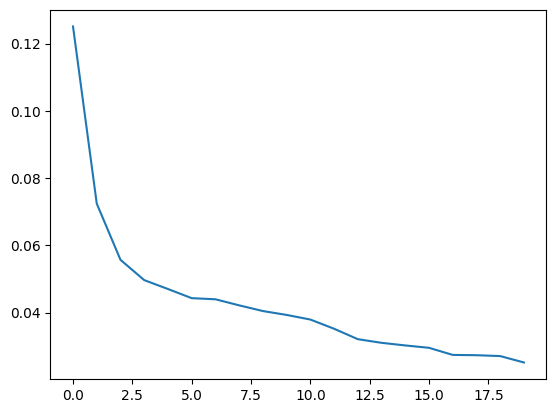

In [18]:
plt.plot(range(len(mca.eigenvalues_)),mca.eigenvalues_)
plt.show()

In [19]:
# 1. Setup your data
Q = np.shape(genres_dummies_clean)[1]
# Replace these with your actual eigenvalues from the table
eigenvalues = mca.eigenvalues_[mca.eigenvalues_ > 1/Q]

def calculate_mca_adjustment(lambdas, q):
    threshold = 1 / q
    adjusted_lambdas = []
    
    for l in lambdas:
        if l > threshold:
            # Applying Benzecri's Formula
            adj = ((q / (q - 1))**2) * ((l - threshold)**2)
            adjusted_lambdas.append(adj)
        else:
            # Dimensions below 1/Q are considered noise and ignored in adjustment
            adjusted_lambdas.append(0)
            
    # Calculate percentages based on the sum of adjusted inertias
    total_adj_inertia = sum(adjusted_lambdas)
    adj_percentages = [(a / total_adj_inertia) * 100 for a in adjusted_lambdas]
    
    return adjusted_lambdas, adj_percentages

# 2. Run calculation
adj_values, adj_percents = calculate_mca_adjustment(eigenvalues, Q)

# 3. Display Results
results = pd.DataFrame({
    'Raw Eigenvalue': eigenvalues,
    'Adjusted Eigenvalue': adj_values,
    'Adjusted %': [f"{p:.2f}%" for p in adj_percents]
})

print(f"Threshold (1/Q): {1/Q:.4f}")
print(results)

Threshold (1/Q): 0.0370
    Raw Eigenvalue  Adjusted Eigenvalue Adjusted %
0         0.125093         8.361701e-03     79.44%
1         0.072430         1.350900e-03     12.83%
2         0.055711         3.760441e-04      3.57%
3         0.049679         1.723444e-04      1.64%
4         0.047033         1.077580e-04      1.02%
5         0.044312         5.707279e-05      0.54%
6         0.043982         5.201532e-05      0.49%
7         0.042176         2.848456e-05      0.27%
8         0.040483         1.280725e-05      0.12%
9         0.039328         5.661678e-06      0.05%
10        0.037956         9.109548e-07      0.01%


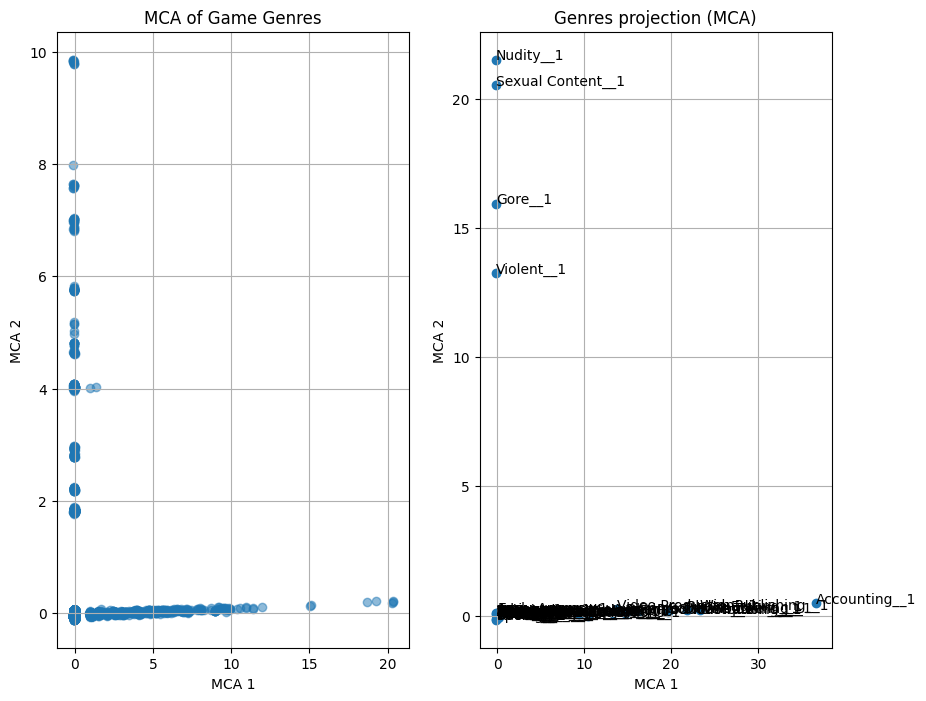

In [20]:
#Projection des individus
plt.figure(figsize = (10,8))
plt.subplot(1,2,1)
plt.scatter(mca_coords[0], mca_coords[1], alpha=0.5)
plt.xlabel("MCA 1")
plt.ylabel("MCA 2")
plt.title("MCA of Game Genres")
plt.grid()

genre_coords = mca.column_coordinates(genres_dummies_clean)
plt.subplot(1,2,2)
plt.scatter(genre_coords[0], genre_coords[1])

for i, txt in enumerate(genre_coords.index):
    plt.text(genre_coords.iloc[i, 0], genre_coords.iloc[i, 1], txt)

plt.xlabel("MCA 1")
plt.ylabel("MCA 2")
plt.title("Genres projection (MCA)")
plt.grid()
plt.show()

In [21]:
mca.plot(
    genres_dummies_clean,
    x_component=0,
    y_component=1,
    show_column_markers=True,
    show_row_markers=False,
    show_column_labels=False,
    show_row_labels=False
)

alt.LayerChart(...)

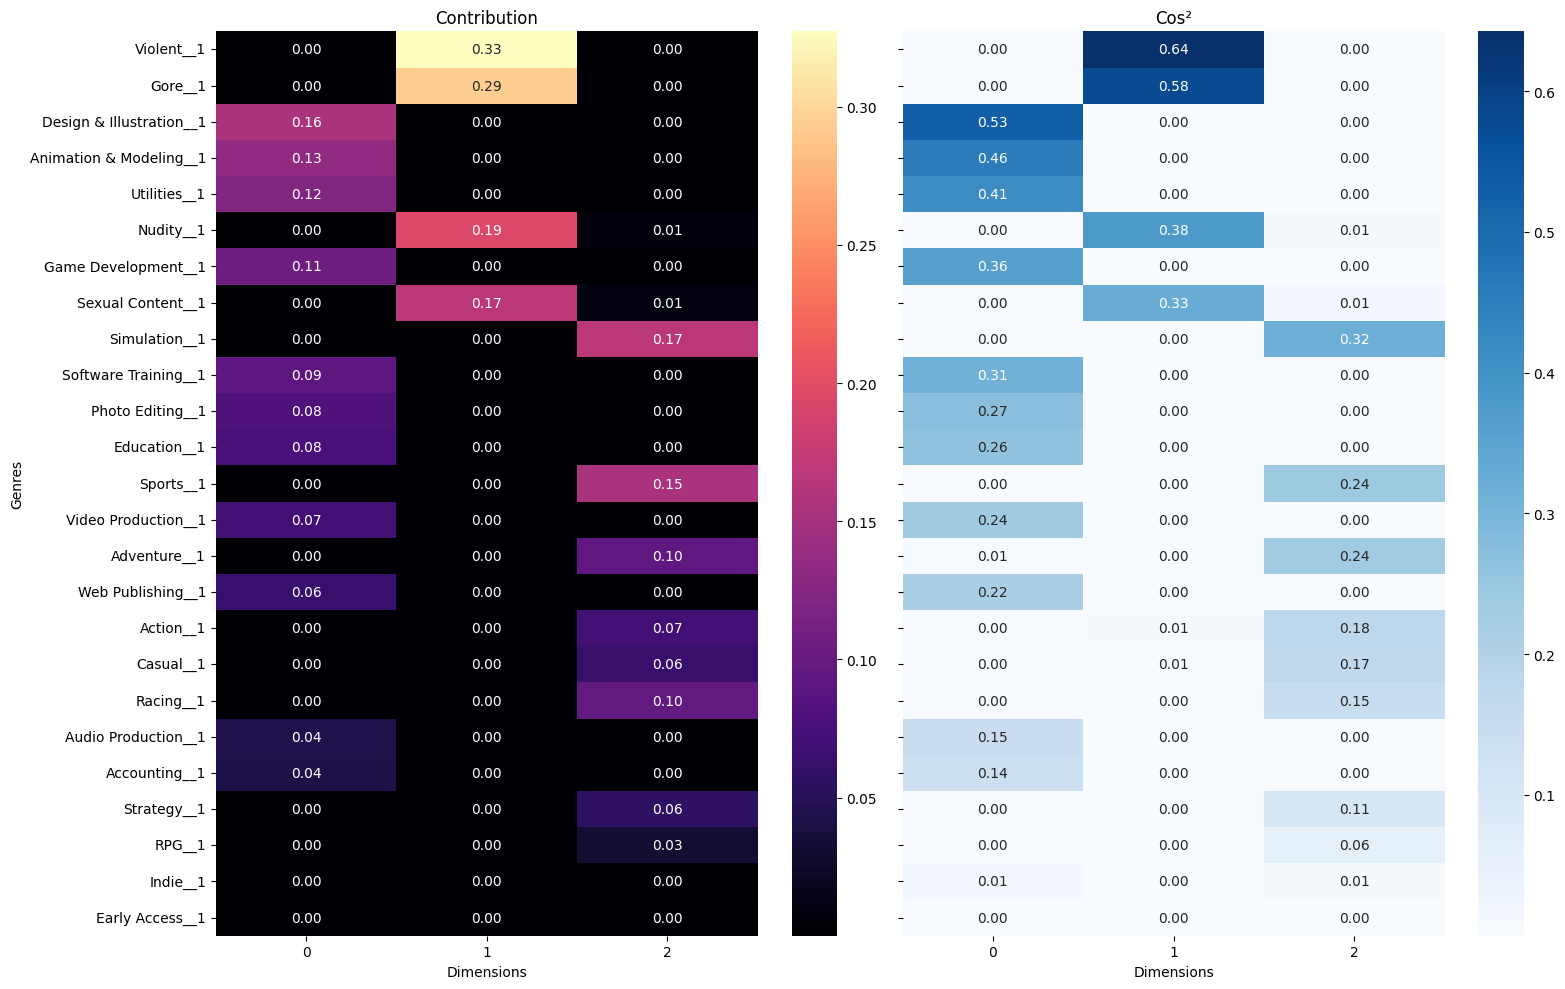

In [22]:
top=2
contrib = mca.column_contributions_
# --- matrices ---
cos2 = mca.column_cosine_similarities(genres_dummies_clean)
mat_cos2 = cos2[cos2.index.str.endswith("_1")].iloc[:, :(top+1)]
mat_contrib = contrib[contrib.index.str.endswith("_1")].iloc[:, :(top+1)]

# --- choose rows to display: top from either contrib or cos2 ---
top_n = 12
top_rows = set()

for c in mat_cos2.columns:
    top_rows.update(mat_cos2[c].nlargest(top_n).index)
    top_rows.update(mat_contrib[c].nlargest(top_n).index)

top_rows = list(top_rows)

# optional: order rows by strongest value overall
row_order = (
    pd.concat(
        [mat_cos2.loc[top_rows].max(axis=1), mat_contrib.loc[top_rows].max(axis=1)],
        axis=1
    )
    .max(axis=1)
    .sort_values(ascending=False)
    .index
)

mat_cos2_plot = mat_cos2.loc[row_order]
mat_contrib_plot = mat_contrib.loc[row_order]

# --- plot side by side ---
fig, axes = plt.subplots(
    1, 2, figsize=(16, max(6, 0.4 * len(row_order))), sharey=True
)

sns.heatmap(
    mat_contrib_plot,
    annot=True, fmt=".2f", cmap="magma",
    ax=axes[0], cbar=True
)
axes[0].set_title("Contribution")
axes[0].set_xlabel("Dimensions")
axes[0].set_ylabel("Genres")

sns.heatmap(
    mat_cos2_plot,
    annot=True, fmt=".2f", cmap="Blues",
    ax=axes[1], cbar=True
)
axes[1].set_title("Cos²")
axes[1].set_xlabel("Dimensions")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Commentaires:**
- Selon le [Adjusted principal inertias](https://statmath.wu.ac.at/courses/CAandRelMeth/caipA.pdf) les 2 premières axes correspondent aux plupart de l'inertie des données.
- La première composante est associée aux software/outils, i.e. 'non-jeux' applications dans le marché. Dans le but d'analyser le marché des jeux, on ne les considère pas dans notre analyse. 

## Filtrer des jeux

In [23]:
genres_dummies_clean.columns

Index(['Accounting', 'Action', 'Adventure', 'Animation & Modeling',
       'Audio Production', 'Casual', 'Design & Illustration', 'Early Access',
       'Education', 'Free To Play', 'Game Development', 'Gore', 'Indie',
       'Massively Multiplayer', 'Nudity', 'Photo Editing', 'RPG', 'Racing',
       'Sexual Content', 'Simulation', 'Software Training', 'Sports',
       'Strategy', 'Utilities', 'Video Production', 'Violent',
       'Web Publishing'],
      dtype='object')

In [24]:
list_to_drop = ['Animation & Modeling',
       'Audio Production', 'Design & Illustration', 'Game Development','Photo Editing', 'Software Training', 'Utilities', 'Video Production',
       'Web Publishing', 'Education', 'Accounting']

In [25]:
genres_dummies_clean2 = genres_dummies_clean.drop(columns = list_to_drop)
genres_dummies_clean2 = genres_dummies_clean2[genres_dummies_clean2.sum(axis=1) != 0]
genres_dummies_clean2.head()

,Action,Adventure,Casual,Early Access,Free To Play,Gore,Indie,Massively Multiplayer,Nudity,RPG,Racing,Sexual Content,Simulation,Sports,Strategy,Violent
AppID,,,,,,,,,,,,,,,,
10,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
20,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
30,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
40,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
50,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [26]:
mca2 = prince.MCA(
    n_components=20,
    n_iter=5,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mca2 = mca2.fit(genres_dummies_clean2)

# Transform to MCA space
row_coords = mca2.transform(genres_dummies_clean2)

In [27]:
mca2.plot(
    genres_dummies_clean2,
    x_component=0,
    y_component=1,
    show_column_markers=True,
    show_row_markers=False,
    show_column_labels=False,
    show_row_labels=False
)

alt.LayerChart(...)

### Nombre de dimensions

In [28]:
1/np.shape(genres_dummies_clean2)[1]

0.0625

In [29]:
mca2.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.122,12.22%,12.22%
1,0.094,9.42%,21.64%
2,0.084,8.38%,30.03%
3,0.079,7.94%,37.97%
4,0.075,7.46%,45.43%
5,0.071,7.09%,52.53%
6,0.067,6.69%,59.21%
7,0.064,6.41%,65.62%
8,0.055,5.49%,71.12%


In [30]:
# 1. Setup your data
Q = np.shape(genres_dummies_clean2)[1]
# Replace these with your actual eigenvalues from the table
eigenvalues = mca2.eigenvalues_[mca2.eigenvalues_ > 1/Q]

# 2. Run calculation
adj_values, adj_percents = calculate_mca_adjustment(eigenvalues, Q)

# 3. Display Results
results = pd.DataFrame({
    'Raw Eigenvalue': eigenvalues,
    'Adjusted Eigenvalue': adj_values,
    'Adjusted %': [f"{p:.2f}%" for p in adj_percents]
})

print(f"Threshold (1/Q): {1/Q:.4f}")
print(results)

Threshold (1/Q): 0.0625
   Raw Eigenvalue  Adjusted Eigenvalue Adjusted %
0        0.122234             0.004060     64.24%
1        0.094180             0.001142     18.07%
2        0.083848             0.000519      8.20%
3        0.079439             0.000326      5.17%
4        0.074640             0.000168      2.65%
5        0.070924             0.000081      1.28%
6        0.066884             0.000022      0.35%
7        0.064086             0.000003      0.05%


### Contribution et Cosine similarité

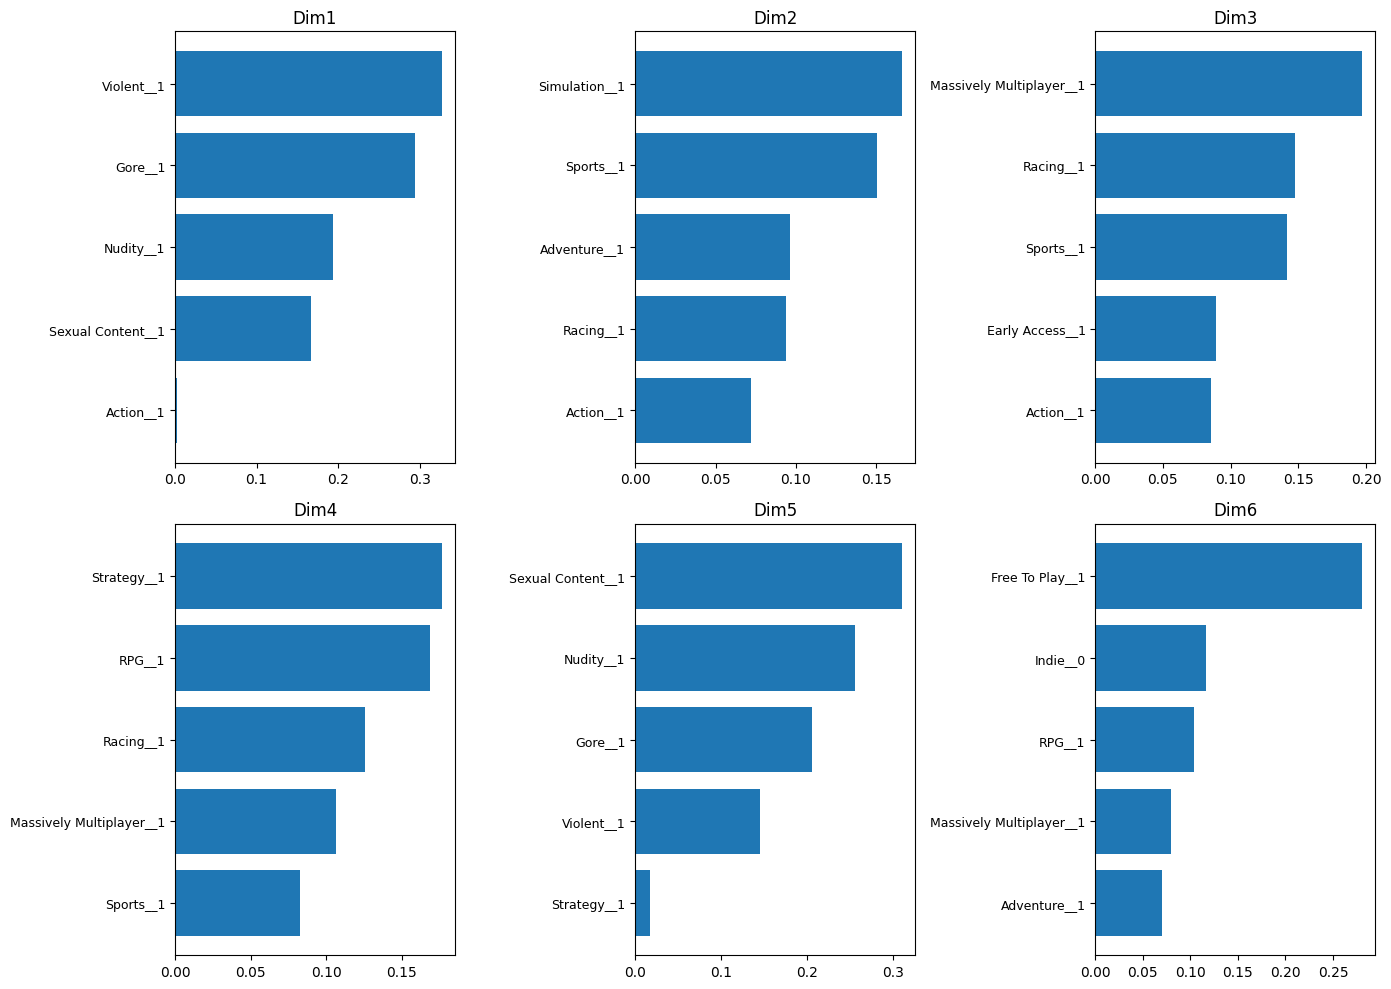

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()
contrib = mca2.column_contributions_
for i, ax in enumerate(axes):
    top = contrib.iloc[:, i].sort_values(ascending=False).head(5)
    ax.barh(top.index[::-1], top.values[::-1])
    ax.set_title(f"Dim{i+1}")
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

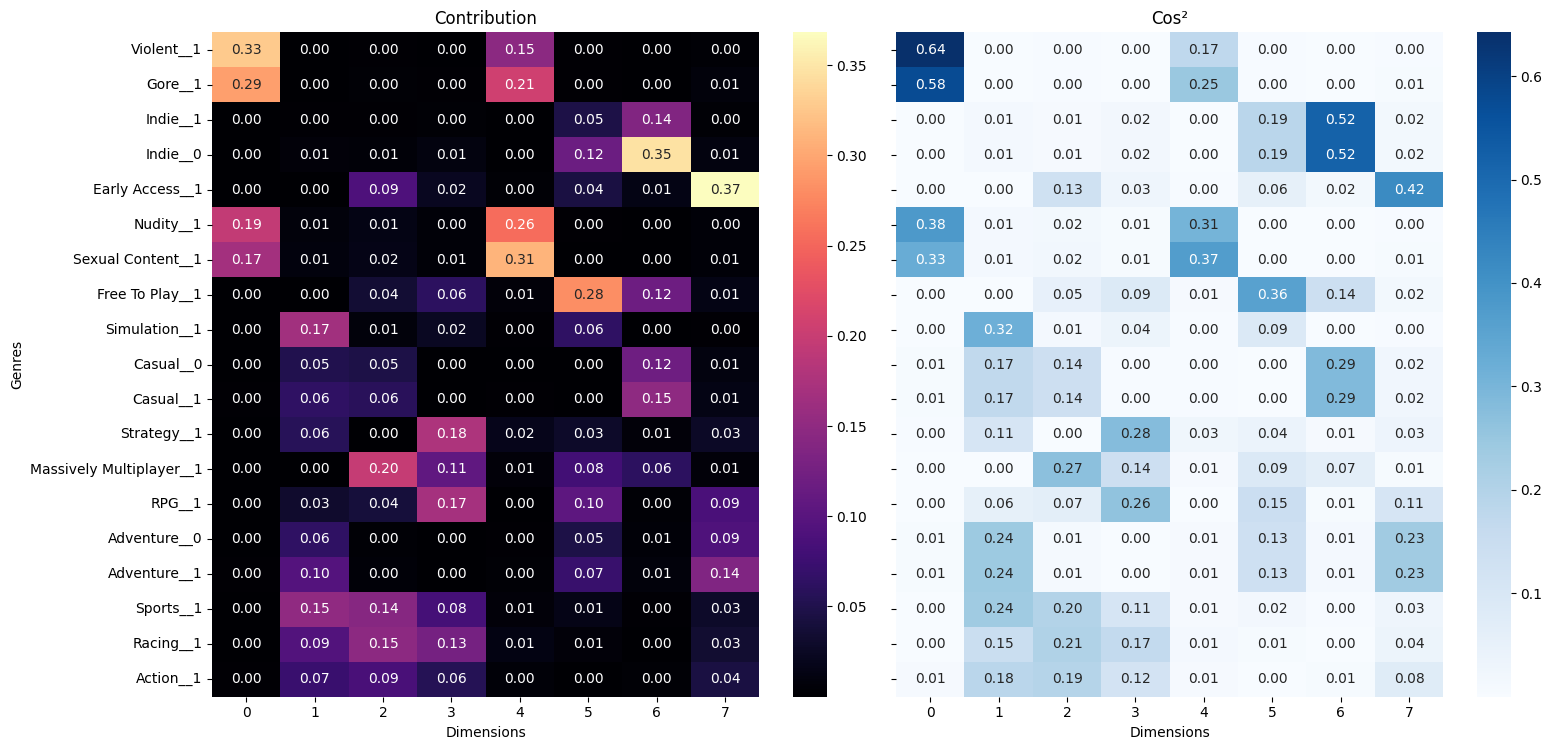

In [32]:
top=7
contrib = mca2.column_contributions_
# --- matrices ---
cos2 = mca2.column_cosine_similarities(genres_dummies_clean2)
mat_cos2 = cos2.iloc[:, :(top+1)]
mat_contrib = contrib.iloc[:, :(top+1)]

# --- choose rows to display: top from either contrib or cos2 ---
top_n = 5
top_rows = set()

for c in mat_cos2.columns:
    top_rows.update(mat_contrib[c].nlargest(top_n).index)
    top_rows.update(mat_cos2[mat_cos2.index.str.endswith("__1")][c].nlargest(top_n).index)

top_rows = list(top_rows)

# optional: order rows by strongest value overall
row_order = (
    pd.concat(
        [mat_cos2.loc[top_rows].max(axis=1), mat_contrib.loc[top_rows].max(axis=1)],
        axis=1
    )
    .max(axis=1)
    .sort_values(ascending=False)
    .index
)

mat_cos2_plot = mat_cos2.loc[row_order]
mat_contrib_plot = mat_contrib.loc[row_order]

# --- plot side by side ---
fig, axes = plt.subplots(
    1, 2, figsize=(16, max(6, 0.4 * len(row_order))), sharey=True
)

sns.heatmap(
    mat_contrib_plot,
    annot=True, fmt=".2f", cmap="magma",
    ax=axes[0], cbar=True
)
axes[0].set_title("Contribution")
axes[0].set_xlabel("Dimensions")
axes[0].set_ylabel("Genres")

sns.heatmap(
    mat_cos2_plot,
    annot=True, fmt=".2f", cmap="Blues",
    ax=axes[1], cbar=True
)
axes[1].set_title("Cos²")
axes[1].set_xlabel("Dimensions")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Coordonnées

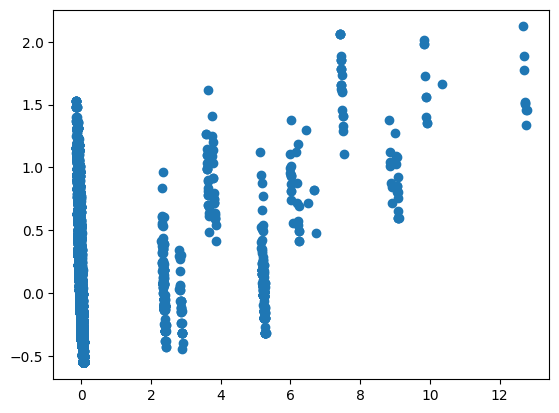

In [33]:
plt.scatter(row_coords.iloc[:,0], row_coords.iloc[:,1])

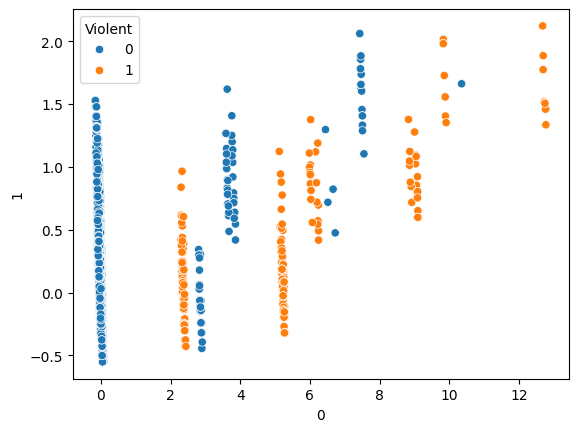

In [34]:
sns.scatterplot(data=row_coords, x=0, y=1, hue=genres_dummies_clean2.loc[row_coords.index,"Violent"])
plt.show()

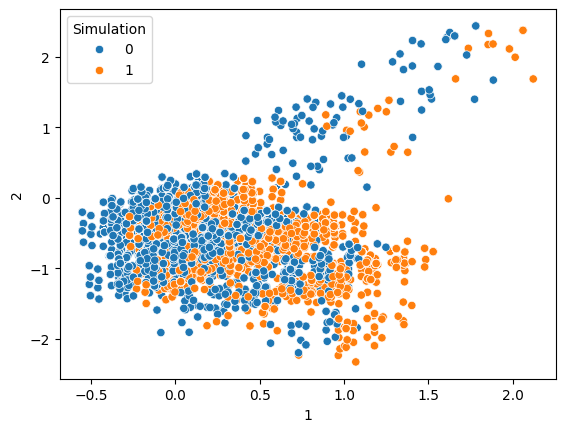

In [35]:
sns.scatterplot(data=row_coords, x=1, y=2, hue=genres_dummies_clean2.loc[row_coords.index,"Simulation"])
plt.show()

In [36]:
def select_modalities_by_axis(coords, cos2,dims=(0, 1),top_n=5):
    '''
    Choisir les modalités les plus importantes
    '''
    selected = set()
    for d in dims:
        selected.update(cos2[d].nlargest(top_n).index)
    return coords.loc[sorted(selected)]
def plot_mca_coords(active_coords, supp_coords=None,dim_x=0,dim_y=1,figsize=(10, 8),title=None):
    fig, ax = plt.subplots(figsize=figsize)

    # Active variables
    ax.scatter(active_coords[dim_x], active_coords[dim_y],
               s=50, label="Active modalities")

    for label, (x, y) in active_coords[[dim_x, dim_y]].iterrows():
        ax.text(x, y, label, fontsize=9, alpha=0.9)

    # Supplementary variables
    if supp_coords is not None:
        ax.scatter(supp_coords[dim_x], supp_coords[dim_y],
                   s=90, marker='D', label="Supplementary modalities")

        for label, (x, y) in supp_coords[[dim_x, dim_y]].iterrows():
            ax.text(x, y, label, fontsize=10)

    # Axes
    ax.axhline(0, color='gray', linewidth=1)
    ax.axvline(0, color='gray', linewidth=1)

    ax.set_xlabel(f"Dimension {dim_x}")
    ax.set_ylabel(f"Dimension {dim_y}")
    ax.set_title(title if title else f"MCA coordinates: Dim {dim_x+1} vs Dim {dim_y+1}")
    ax.legend()
    plt.tight_layout()
    plt.show()

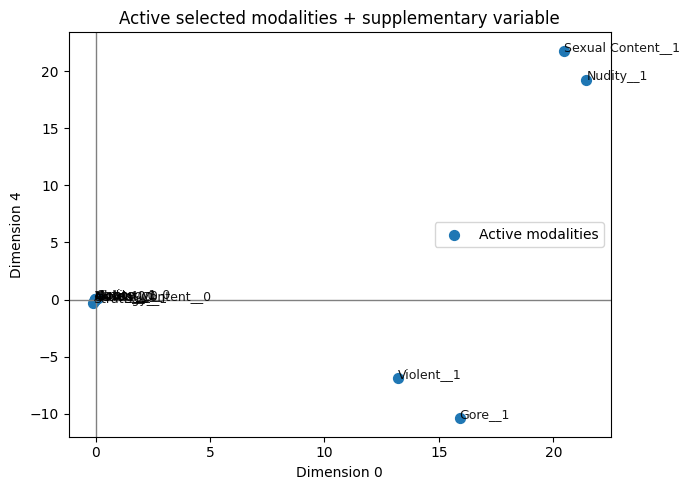

In [37]:
d1, d2 = 0, 4
top=5
active_coords_sel = select_modalities_by_axis(mca2.column_coordinates(genres_dummies_clean2), cos2,dims=(d1, d2),top_n=top*2)
plot_mca_coords(
    active_coords=active_coords_sel,
    dim_x=d1,
    dim_y=d2,
    title="Active selected modalities + supplementary variable",
    figsize=(7,5)
)

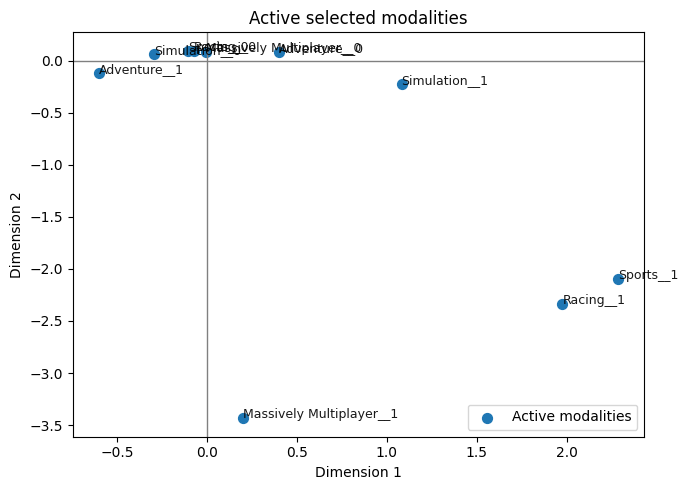

In [38]:
d1, d2 = 1, 2
top=3
active_coords_sel = select_modalities_by_axis(mca2.column_coordinates(genres_dummies_clean2), cos2,dims=(d1, d2),top_n=top*2)
plot_mca_coords(
    active_coords=active_coords_sel,
    dim_x=d1,
    dim_y=d2,
    title="Active selected modalities",
    figsize=(7,5)
)

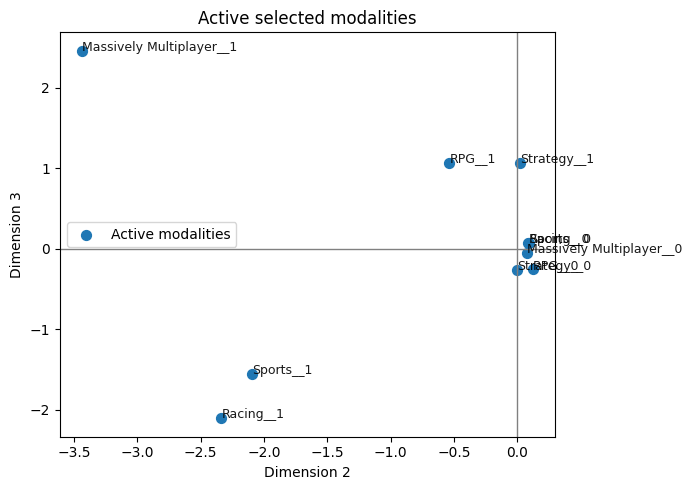

In [39]:
d1, d2 = 2, 3
top=3
active_coords_sel = select_modalities_by_axis(mca2.column_coordinates(genres_dummies_clean2), cos2,dims=(d1, d2),top_n=top*2)
plot_mca_coords(
    active_coords=active_coords_sel,
    dim_x=d1,
    dim_y=d2,
    title="Active selected modalities",
    figsize=(7,5)
)

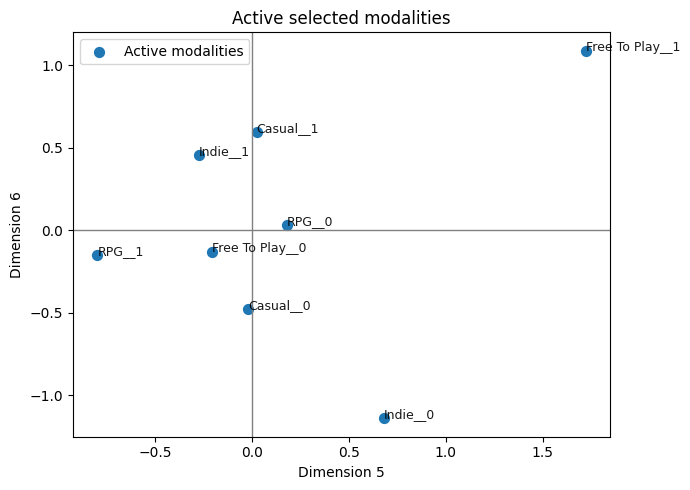

In [40]:
d1, d2 = 5, 6
top=3
active_coords_sel = select_modalities_by_axis(mca2.column_coordinates(genres_dummies_clean2), cos2,dims=(d1, d2),top_n=top*2)
plot_mca_coords(
    active_coords=active_coords_sel,
    dim_x=d1,
    dim_y=d2,
    title="Active selected modalities",
    figsize=(7,5)
)

**Commentaires:**
- Axe 0 (et 4): Sensitivité du contenu :
  - Axe 4 : Violent, gore et contenu sexuel
- Axe 1,2,3 : Jeux d'actions, sports, racing,...
    - Axe 1 : Simulation, Sport >< Adventure => Realistique / simulation-based vs narrative/exploration (adventure)
    - Axe 2 : MMO => Multiplayer scale / social interaction intensity
    - Axe 3 : RPG, Strategie >< Sports, Racing => tatique/complexité vs réflexion/skill-based
- Axe 5 : Free-to-play
- Axe 6 : Indie, Casual
- Axe 7 : Early access

### Owners group

<Axes: xlabel='count', ylabel='Owners group'>

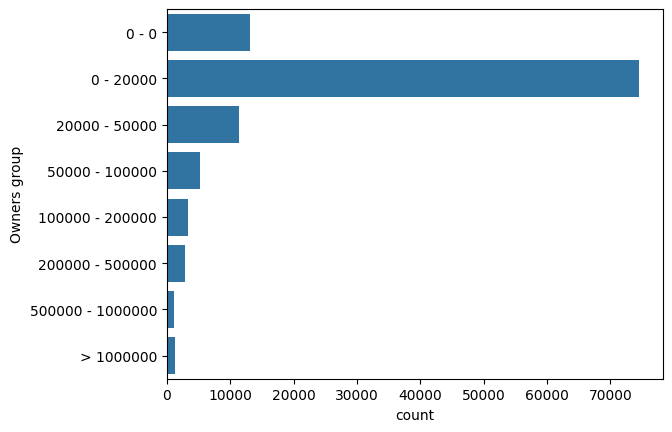

In [41]:
order = [
    "0 - 0",
    "0 - 20000",
    "20000 - 50000",
    "50000 - 100000",
    "100000 - 200000",
    "200000 - 500000",
    "500000 - 1000000",
    "> 1000000"
]
sns.countplot(y="Owners group", data=data, order = order)
#sns.countplot(y="Estimated owners", data=data)


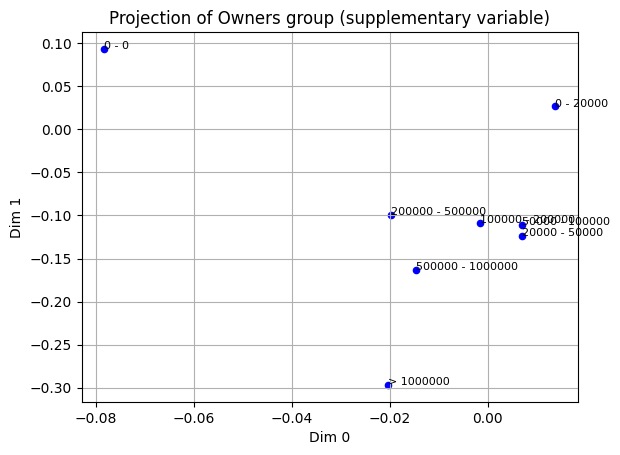

In [42]:
row_coords["Owners group"] = data.loc[row_coords.index,"Owners group"].astype("category")
eig = mca2.eigenvalues_
owners_proj = row_coords.groupby("Owners group", observed=False).mean()
owners_proj_corrected = owners_proj.copy()
owners_proj_corrected = owners_proj / np.sqrt(eig[:owners_proj.shape[1]])

order = [
    "0 - 0",
    "0 - 20000",
    "20000 - 50000",
    "50000 - 100000",
    "100000 - 200000",
    "200000 - 500000",
    "500000 - 1000000",
    "> 1000000"
]

owners_proj_corrected = owners_proj_corrected.loc[order]
# plot points
d1 = 0
d2 = 1
plt.scatter(owners_proj_corrected[d1], owners_proj_corrected[d2], color="blue", s=20)

# labels
for cat in owners_proj.index:
    x = owners_proj_corrected.loc[cat, d1]
    y = owners_proj_corrected.loc[cat, d2]
    plt.text(x, y, cat, fontsize=8)

plt.xlabel(f"Dim {d1}")
plt.ylabel(f"Dim {d2}")
plt.title("Projection of Owners group (supplementary variable)")

plt.grid()
plt.show()

<Axes: ylabel='Owners group'>

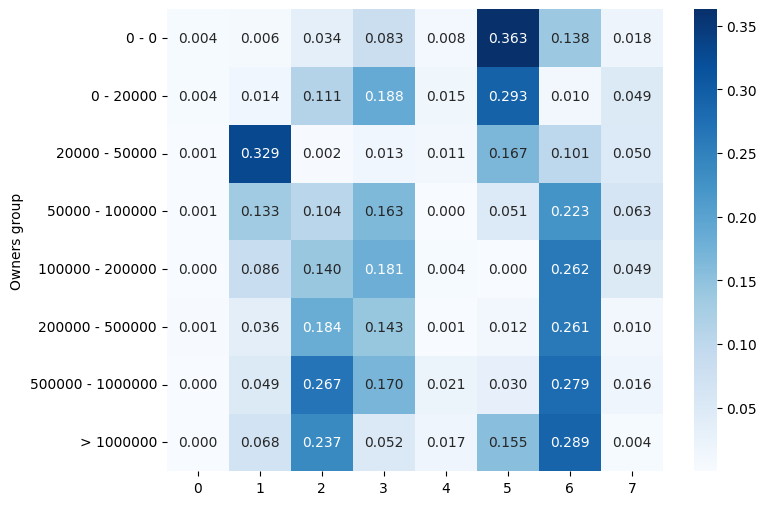

In [43]:
# Cosine similarité de Owners group
df = owners_proj_corrected.iloc[:,:15]
owners_sq = df**2
owners_cos2 = owners_sq.div(owners_sq.sum(axis=1), axis=0)
plt.figure(figsize=(8,6))
sns.heatmap(
    owners_cos2.iloc[:,:8],
    annot=True, fmt=".3f", cmap="Blues", cbar=True
)

**Commentaires:** On s'intéresse aux axes 2,3 et 5,6

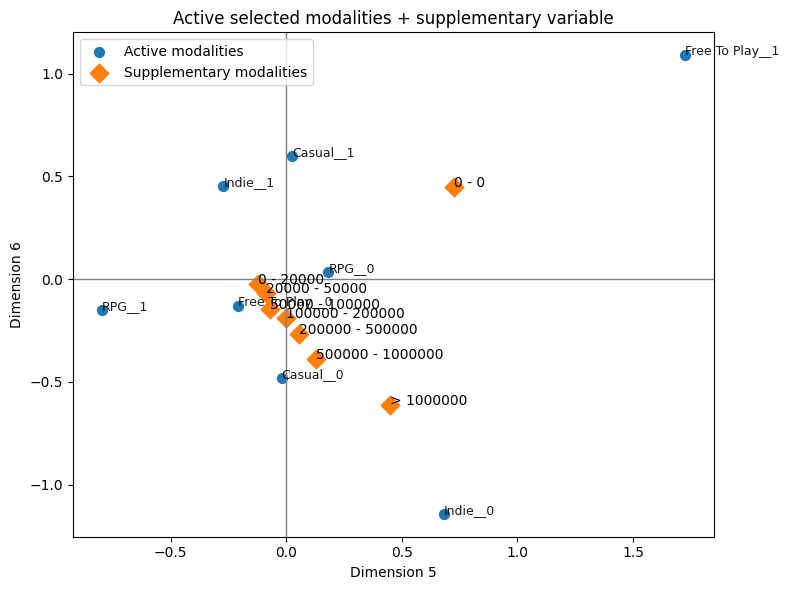

In [44]:
d1, d2 = 5, 6
top=3
active_coords_sel = select_modalities_by_axis(mca2.column_coordinates(genres_dummies_clean2), cos2,dims=(d1, d2),top_n=top*2)
plot_mca_coords(
    active_coords=active_coords_sel,
    supp_coords=owners_proj_corrected,
    dim_x=d1,
    dim_y=d2,
    title="Active selected modalities + supplementary variable",
    figsize=(8,6)
)

**Commentaires**
- Non Indie + Non casual : En général plus de joueurs
- Non Indie : Jeux dévéloppés par de grandes groupes/entreprises, et attirent plus de joueurs. 
- Casual : Casual est les jeux pour la masse, qui sont plus simples, requiertent mois de compétences. Mais cet genre semble n'attire pas beaucoup de joueurs

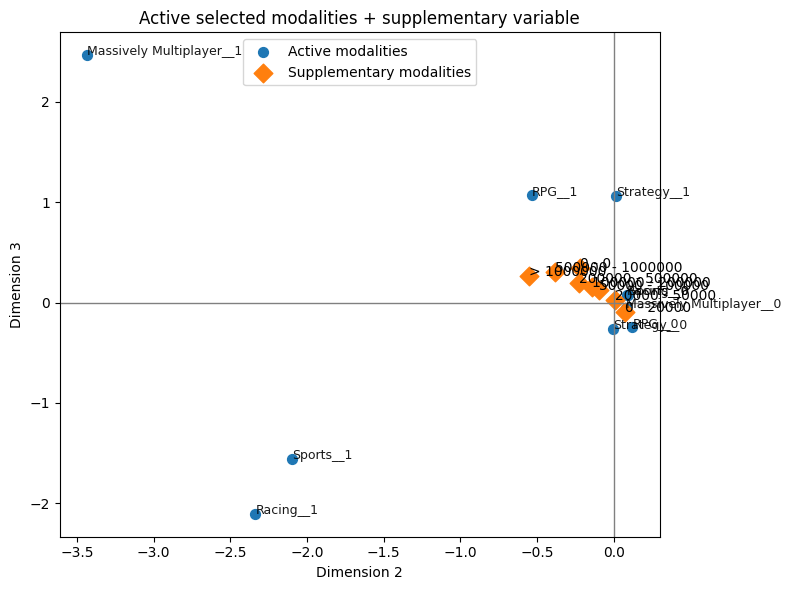

In [45]:
d1, d2 = 2, 3
top=3
active_coords_sel = select_modalities_by_axis(mca2.column_coordinates(genres_dummies_clean2), cos2,dims=(d1, d2),top_n=top*2)
plot_mca_coords(
    active_coords=active_coords_sel,
    supp_coords=owners_proj_corrected,
    dim_x=d1,
    dim_y=d2,
    title="Active selected modalities + supplementary variable",
    figsize=(8,6)
)

**Commentaires:**
- MMO, RPG, stratégie : plus de joueurs
- Les jeux Multiplayer ou tactique semblent associés aux plus grand nombre de joueurs.

### Price

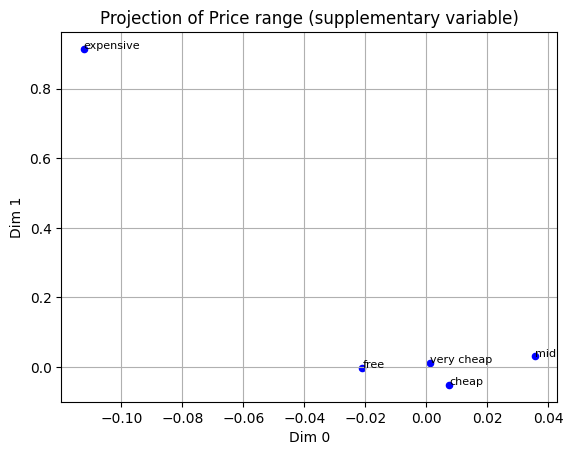

In [46]:
df = row_coords.iloc[:,:-1].copy()
df["Price category"] = data.loc[row_coords.index,"Price category"].astype("category")
eig = mca2.eigenvalues_
price_proj = df.groupby("Price category", observed=False).mean()
price_proj_corrected = price_proj.copy()
for k in range(len(eig)):
    price_proj_corrected[k] = price_proj_corrected[k] / np.sqrt(eig[k])

order = ["free", "very cheap", "cheap", "mid", "expensive"]

price_proj_corrected = price_proj_corrected.loc[order]
# plot points
d1 = 0
d2 = 1
plt.scatter(price_proj_corrected[d1], price_proj_corrected[d2], color="blue", s=20)

# labels
for cat in price_proj.index:
    x = price_proj_corrected.loc[cat, d1]
    y = price_proj_corrected.loc[cat, d2]
    plt.text(x, y, cat, fontsize=8)

plt.xlabel(f"Dim {d1}")
plt.ylabel(f"Dim {d2}")
plt.title("Projection of Price range (supplementary variable)")

plt.grid()
plt.show()

<Axes: ylabel='Price category'>

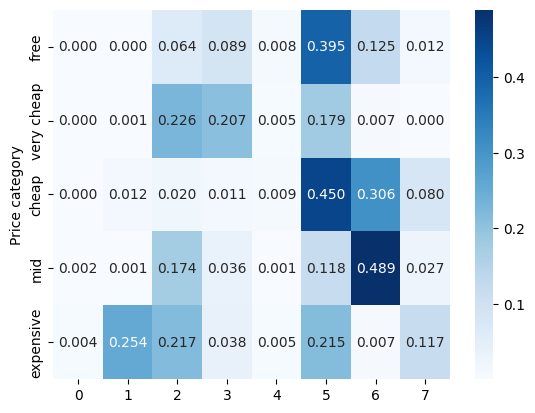

In [47]:
price_sq = price_proj_corrected.iloc[:,:15]**2
price_cos2 = price_sq.div(price_sq.sum(axis=1), axis=0)
sns.heatmap(
    price_cos2.iloc[:,:8],
    annot=True, fmt=".3f", cmap="Blues", cbar=True
)

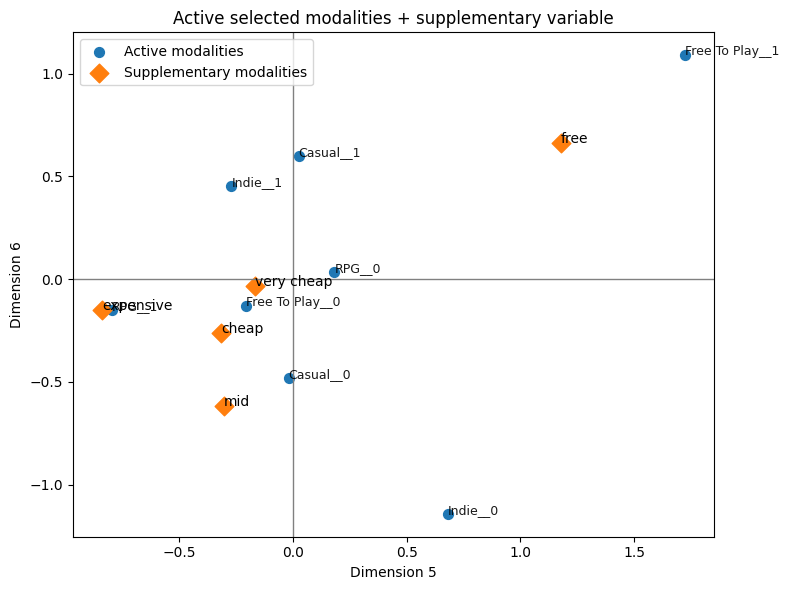

In [48]:
d1, d2 = 5, 6
top=3
active_coords_sel = select_modalities_by_axis(mca2.column_coordinates(genres_dummies_clean2), cos2,dims=(d1, d2),top_n=top*2)
plot_mca_coords(
    active_coords=active_coords_sel,
    supp_coords=price_proj_corrected,
    dim_x=d1,
    dim_y=d2,
    title="Active selected modalities + supplementary variable",
    figsize=(8,6)
)

**Commentaires** Les jeux non casual et non Indie one associés au prix moyen ou bas.

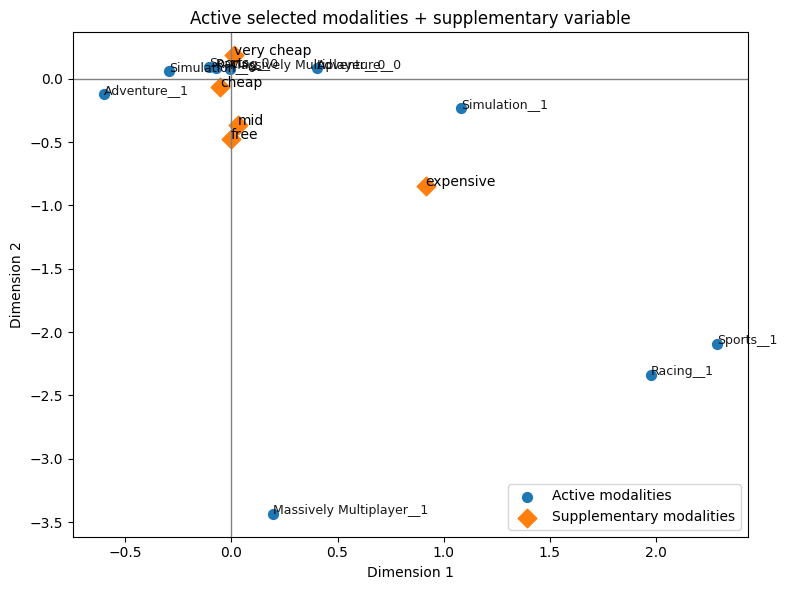

In [49]:
d1, d2 = 1, 2
top=3
active_coords_sel = select_modalities_by_axis(mca2.column_coordinates(genres_dummies_clean2), cos2,dims=(d1, d2),top_n=top*2)
plot_mca_coords(
    active_coords=active_coords_sel,
    supp_coords=price_proj_corrected,
    dim_x=d1,
    dim_y=d2,
    title="Active selected modalities + supplementary variable",
    figsize=(8,6)
)

**Commentaires:** Simulation, sports, racing sont associés au prix élevé

### Conclusion
- Axes latents :
    - Axe 0 (et 4): Sensitivité du contenu :
        - Axe 4 : Violent, gore et contenu sexuel
    - Axe 1,2,3 : Jeux d'actions, sports, racing,...
        - Axe 1 : Realistique / simulation-based vs narrative/exploration (adventure)
        - Axe 2 : Multiplayer scale / social interaction intensity
        - Axe 3 : Tatique/complexité vs réflexion/skill-based
    - Axe 5 : Gratuité
    - Axe 6 : Indie, Casual
    - Axe 7 : Early access
- Nombre de joueurs:
    - Non indie + non casual : Plus de joueurs
    - Multiplayer, tactique (MMO, RPG, Stratégie) : Plus de joueurs
- Prix :
    - Non casual : Prix bas, moyen
    - Simulation, sports, racing : Prix élevé

## Clustering

Le but de cette partie est : 
- Déterminer la sefmentation du marché
- Niches de marché

Pour la première question, on va utiliser Kmeans ou GMM,... et pour la 2e on utilisera HDBSCAN.

### Segmentation du marché

In [68]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(row_coords.iloc[:, :8])
df_clusters = genres_dummies_clean2.copy()
df_clusters["price"] = data.loc[row_coords.index,"Price category"].astype("category")
df_clusters["owners"] = data.loc[row_coords.index,"Owners group"].astype("category")
df_clusters["nb_sensitive"] = ((df_clusters["Violent"] +
    df_clusters["Nudity"] +
    df_clusters["Gore"] +
    df_clusters["Sexual Content"]
) >0).astype(int)
df_clusters["real vs adventure"] = ((df_clusters["Simulation"] + 
                                   df_clusters["Sports"] +
                                   df_clusters["Racing"])>0).astype(int) -df_clusters["Adventure"]
df_clusters["tactique vs skills"] = ((df_clusters["RPG"] + 
                                   df_clusters["Strategy"])>0).astype(int) -(( 
                                   df_clusters["Sports"] +
                                   df_clusters["Racing"])>0).astype(int)
df_clusters["Indie/casual"] = ((df_clusters["Indie"] + 
                                   df_clusters["Casual"])>0).astype(int) 

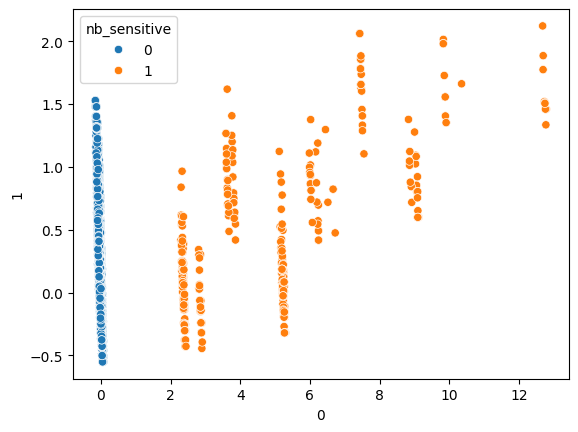

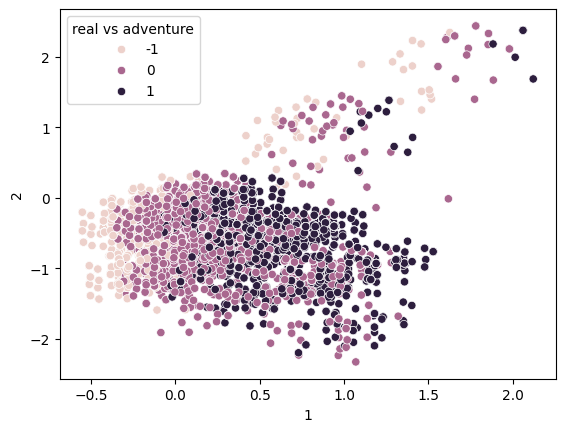

In [69]:
sns.scatterplot(data=row_coords, x=0, y=1, hue=df_clusters["nb_sensitive"])
plt.show()
sns.scatterplot(data=row_coords, x=1, y=2, hue=df_clusters["real vs adventure"])
plt.show()

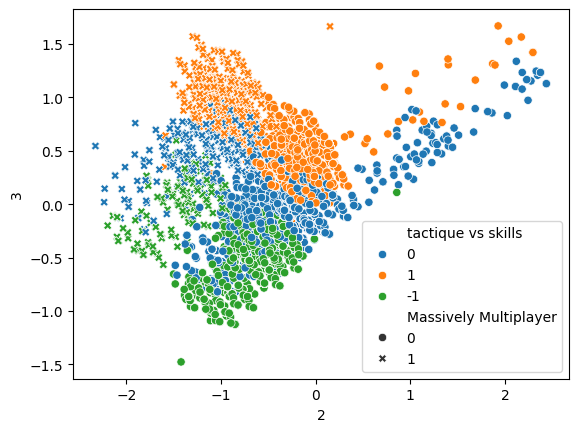

In [70]:
sns.scatterplot(data=row_coords, x=2, y=3,hue=df_clusters["tactique vs skills"].astype(str), 
                style=df_clusters["Massively Multiplayer"].astype(str))
plt.show()

<Axes: xlabel='5', ylabel='6'>

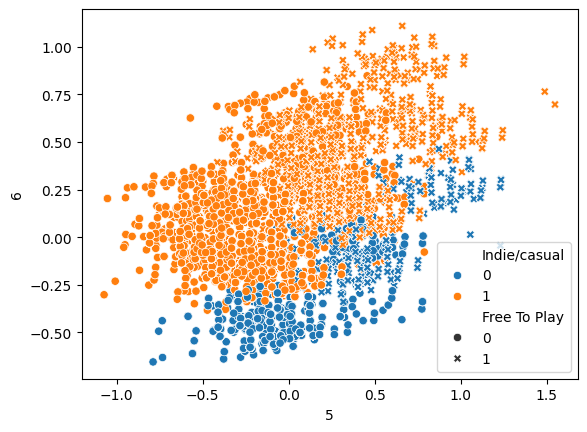

In [71]:
sns.scatterplot(data=row_coords, x=5, y=6,hue=df_clusters["Indie/casual"].astype(str), 
                style=df_clusters["Free To Play"].astype(str))

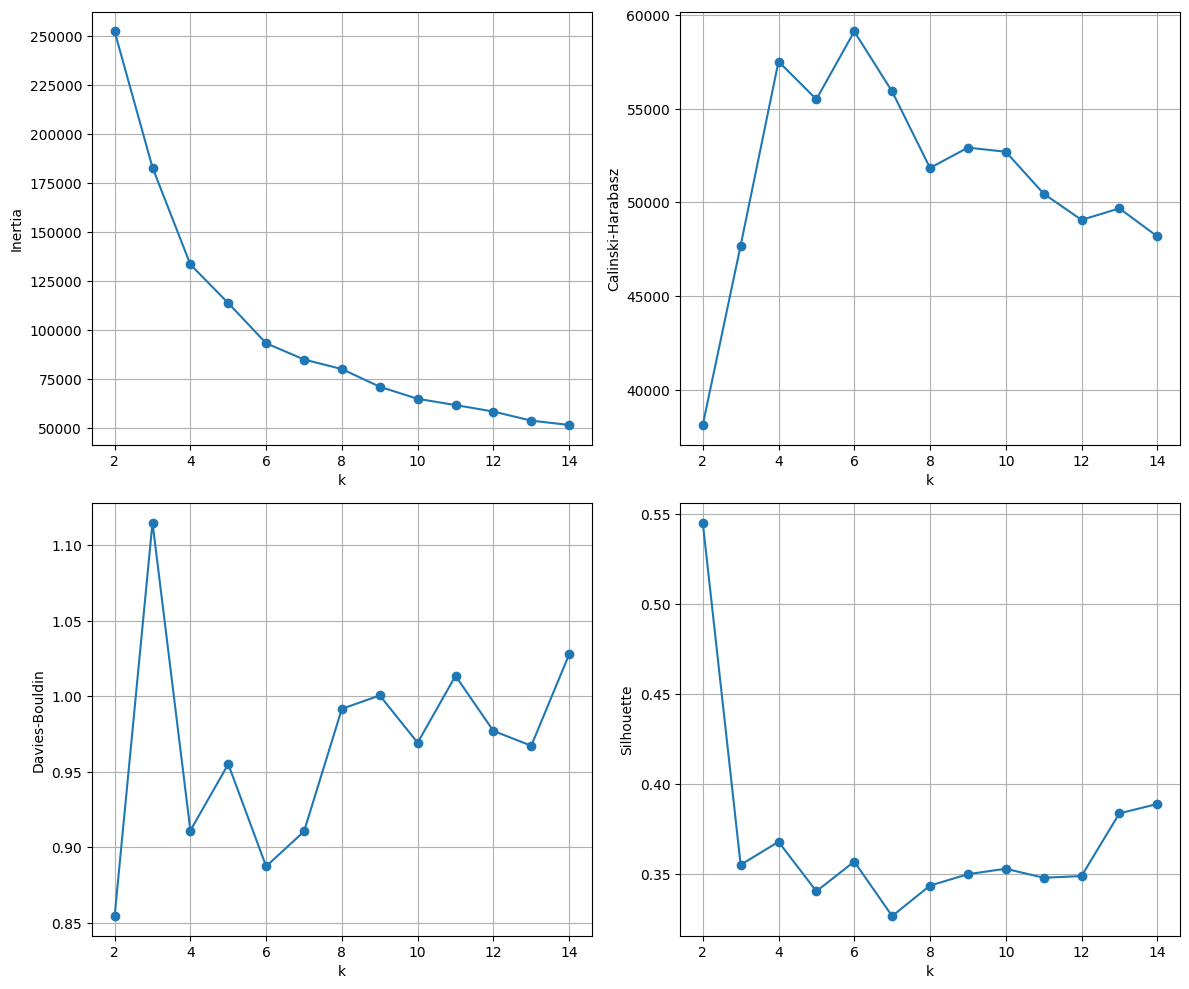

In [73]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score,silhouette_score

inertia = []
ch = []
db = []
silhouette = []
K_range = range(2,15)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_scaled[:,1:4])
    inertia.append(kmeans.inertia_)
    ch.append(calinski_harabasz_score(X_scaled[:,1:4], kmeans.labels_))
    db.append(davies_bouldin_score(X_scaled[:,1:4], kmeans.labels_))
    idx = np.random.choice(len(X_scaled), 5000, replace=False)
    silhouette.append(silhouette_score(X_scaled[idx,1:4], kmeans.labels_[idx]))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Inertia
axes[0, 0].plot(K_range, inertia, marker='o')
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].grid()

# Calinski-Harabasz
axes[0, 1].plot(K_range, ch, marker='o')
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("Calinski-Harabasz")
axes[0, 1].grid()

# Davies-Bouldin
axes[1, 0].plot(K_range, db, marker='o')
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("Davies-Bouldin")
axes[1, 0].grid()

# Silhouette
axes[1, 1].plot(K_range, silhouette, marker='o')
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("Silhouette")
axes[1, 1].grid()

plt.tight_layout()
plt.show()

**Commentaire:** On va choisir K = 4

In [74]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
reskmeans = kmeans.fit_predict(X_scaled[:,1:4])

In [75]:
reskmeans

array([1, 1, 1, ..., 2, 3, 1], shape=(112631,), dtype=int32)

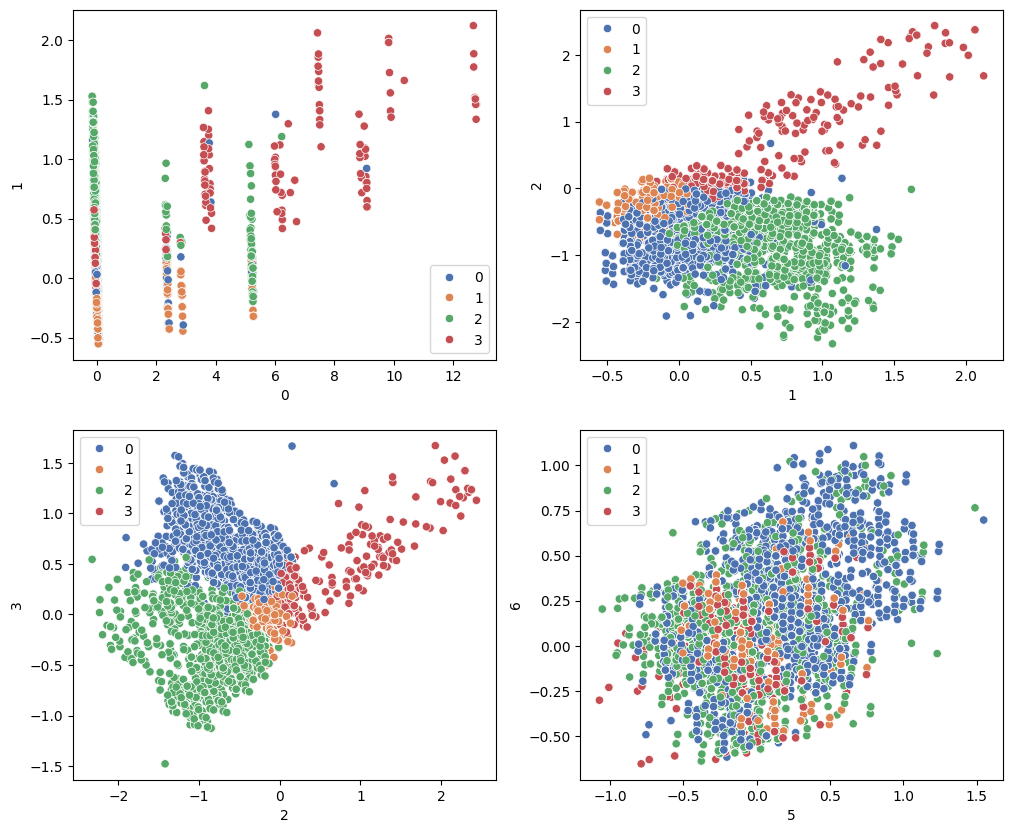

In [76]:
h = reskmeans
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(data=row_coords, x=0, y=1, hue=h,  palette="deep", ax=axes[0,0])
sns.scatterplot(data=row_coords, x=1, y=2, hue=h,  palette="deep", ax=axes[0,1])
sns.scatterplot(data=row_coords, x=2, y=3, hue=h,  palette="deep", ax=axes[1,0])
sns.scatterplot(data=row_coords, x=5, y=6, hue=h,  palette="deep", ax=axes[1,1])
plt.show()

In [77]:
df_clusters["kmeans"] = reskmeans

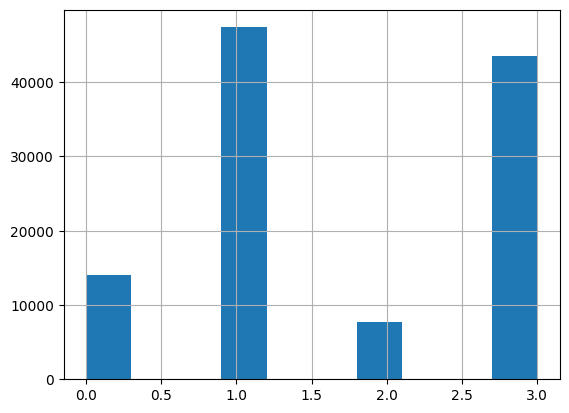

In [78]:
plt.hist(reskmeans)
plt.grid()
plt.show()

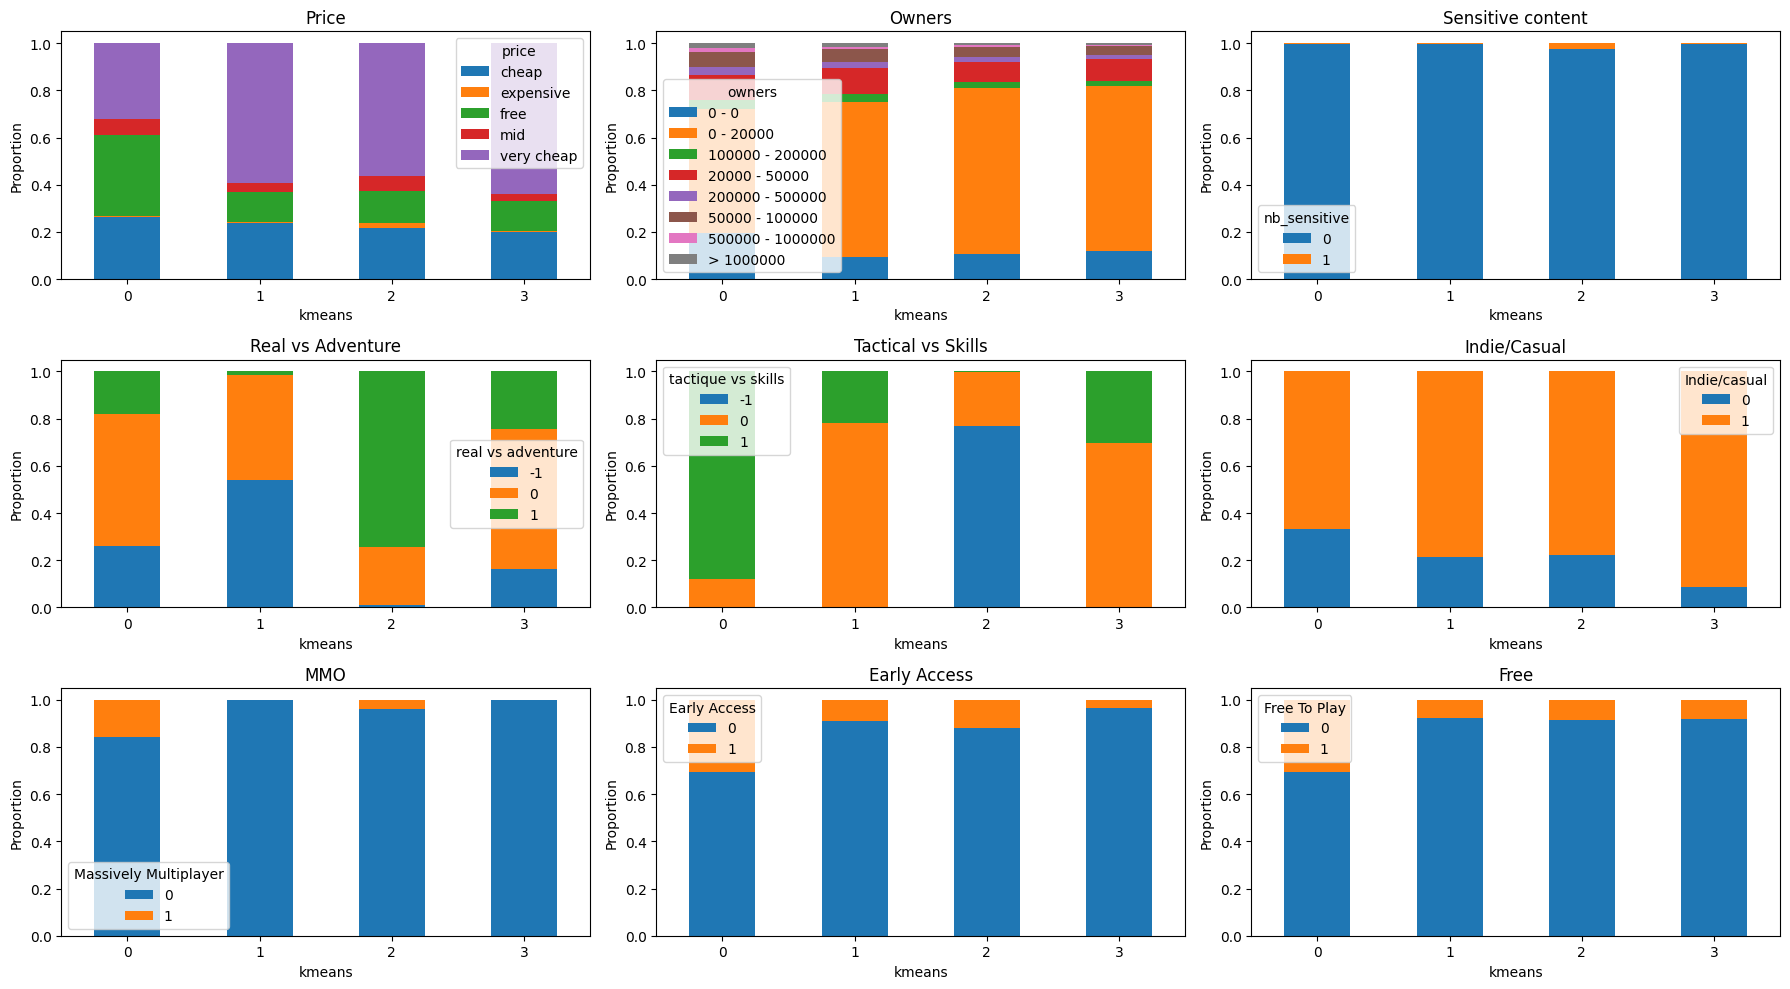

In [79]:
vars_to_plot = [
    ("price", "Price"),
    ("owners", "Owners"),
    ("nb_sensitive", "Sensitive content"),
    ("real vs adventure", "Real vs Adventure"),
    ("tactique vs skills", "Tactical vs Skills"),
    ("Indie/casual", "Indie/Casual"),
    ("Massively Multiplayer", "MMO"),
    ("Early Access", "Early Access"),
    ("Free To Play","Free")
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (var, title) in enumerate(vars_to_plot):
    
    dist = (
        df_clusters
        .groupby("kmeans")[var]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )
    
    dist.plot(kind="bar", stacked=True, ax=axes[i])
    
    axes[i].set_title(title)
    axes[i].set_xlabel("kmeans")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

<Axes: xlabel='kmeans'>

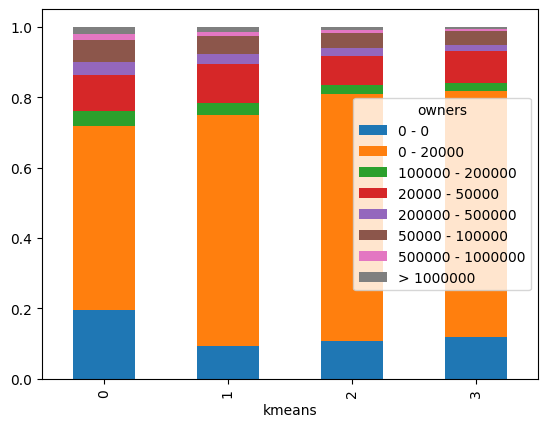

In [80]:
dist = (
        df_clusters
        .groupby("kmeans")['owners']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )
    
dist.plot(kind="bar", stacked=True)

**Remarque:**
- Cluster 0 :
    - bcp de jeux gratuits
    - tactiques
    - MMO
    - bcp Early Access (en comparaison avec les autres)
    - bcp Non Indie, Non casual (en comparaison avec les autres)
    - nb de joueurs varié : bcp populaire (>100k), mais aussi bcp mort
- Cluster 1 : Le plus grand cluster
    - Adventure
    - tactiques vs skills : neutre
    - Prix bas
    - Peu de jeux sans joueurs
- Cluster 2 : Le plus petit cluster
    - Real
    - Skills
    - Prix élevé
- Cluster 3 :
    - Indie, Casual
    - Prix très bas
    - Genre : un peu mixe
    - tactiques vs skills : neutre

In [137]:
data.loc[df_clusters[df_clusters["kmeans"] == 2].index]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,Tags,has_header image,has_screenshots,has_website,has_support url,has_support email,has_about the game,Ratio positive vote,Price category,Owners group
AppID,,,,,,,,,,,,,,,,,,,,,
2990,FlatOut 2,"Dec 21, 2006",500000 - 1000000,85,0,1.99,80,0,"[English, French, German, Italian, Spanish - S...","[English, Traditional Chinese]",...,"[Racing, Combat Racing, Multiplayer, Destructi...",1,1,0,1,1,1,0.960504,very cheap,500000 - 1000000
3010,Xpand Rally,"Aug 24, 2006",20000 - 50000,0,0,0.54,89,0,[English],[],...,"[Racing, Driving, Physics, 3D, Automobile Sim,...",1,1,1,0,0,1,0.836879,very cheap,20000 - 50000
3050,Xpand Rally Xtreme,"Oct 8, 2008",20000 - 50000,0,0,0.54,89,0,[English],[],...,"[Racing, Automobile Sim, Offroad, Simulation, ...",1,1,0,0,0,1,0.771574,very cheap,20000 - 50000
4230,RACE - The WTCC Game,"Nov 24, 2006",0 - 20000,0,0,9.99,75,0,"[English, French, German, Italian, Spanish - S...",[],...,"[Racing, Automobile Sim, Driving, Simulation]",1,1,1,0,1,1,0.743590,cheap,0 - 20000
4290,RACE: Caterham Expansion,"Jun 22, 2007",0 - 20000,0,0,1.99,50,0,[English],[],...,"[Racing, Driving, Automobile Sim, Simulation]",1,1,1,0,0,1,0.461538,very cheap,0 - 20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4239980,Cube Dodger 3D,"Dec 24, 2025",0 - 0,0,0,0.00,0,12,[English],[],...,[],1,1,1,1,1,1,NaN,free,0 - 0
4246050,Through Space,"Dec 25, 2025",0 - 0,0,0,4.19,0,0,"[English, Russian]","[English, Russian]",...,[],1,1,0,0,1,1,NaN,very cheap,0 - 0
4247480,Endless Racing,"Dec 30, 2025",0 - 0,0,0,1.49,0,0,"[English, French, Italian, German, Spanish - S...",[],...,[],1,1,0,0,1,1,NaN,very cheap,0 - 0


### Niche

In [81]:
from sklearn.cluster import HDBSCAN

In [88]:
X_niche = X_scaled[reskmeans==0,1:4]
data_niche = row_coords[reskmeans==0]
X_niche

array([[ 0.00646214, -0.76129534,  1.1234522 ],
       [-0.38995871, -0.04614819,  0.92449198],
       [-0.38995871, -0.04614819,  0.92449198],
       ...,
       [ 1.06981488, -0.2453768 ,  2.34001563],
       [ 0.09943302, -0.67563734,  0.52876037],
       [-0.38995871, -0.04614819,  0.92449198]], shape=(14027, 3))

In [109]:
hdb = HDBSCAN(copy = False,min_cluster_size=500,min_samples=10, n_jobs=-1,metric='euclidean',cluster_selection_method='eom')
labels_hdb = hdb.fit_predict(X_niche)

In [110]:
np.unique(hdb.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7])

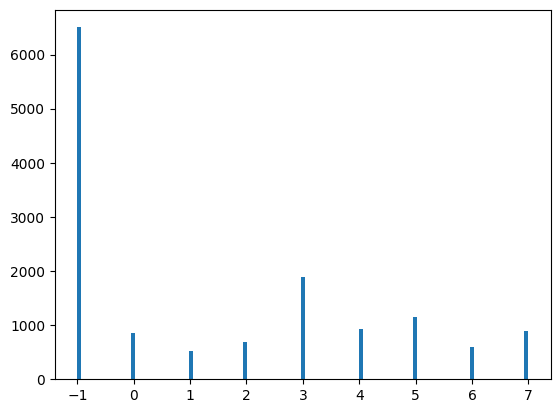

In [111]:
plt.hist(hdb.labels_,bins=117)
plt.show()

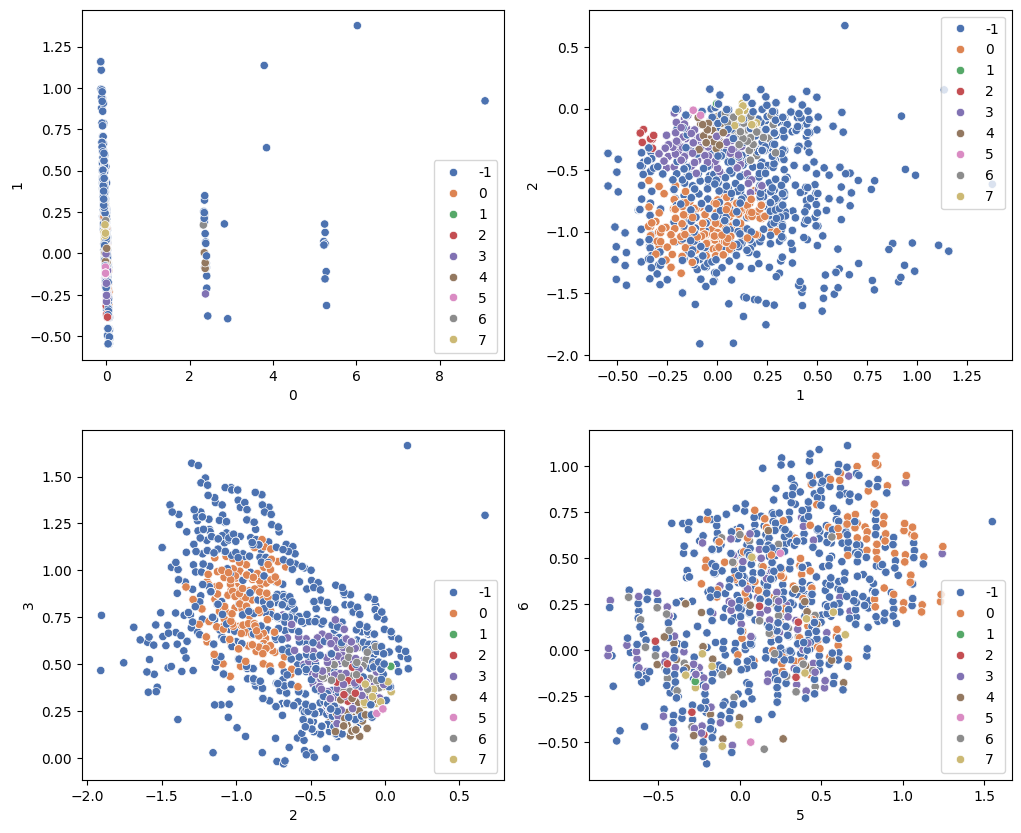

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(data=data_niche, x=0, y=1, hue=labels_hdb,  palette="deep", ax=axes[0,0])
sns.scatterplot(data=data_niche, x=1, y=2, hue=labels_hdb,  palette="deep", ax=axes[0,1])
sns.scatterplot(data=data_niche, x=2, y=3, hue=labels_hdb,  palette="deep", ax=axes[1,0])
sns.scatterplot(data=data_niche, x=5, y=6, hue=labels_hdb,  palette="deep", ax=axes[1,1])
plt.show()

In [113]:
coord_niche = df_clusters[reskmeans==0].copy()
coord_niche["hdbscan"] = labels_hdb

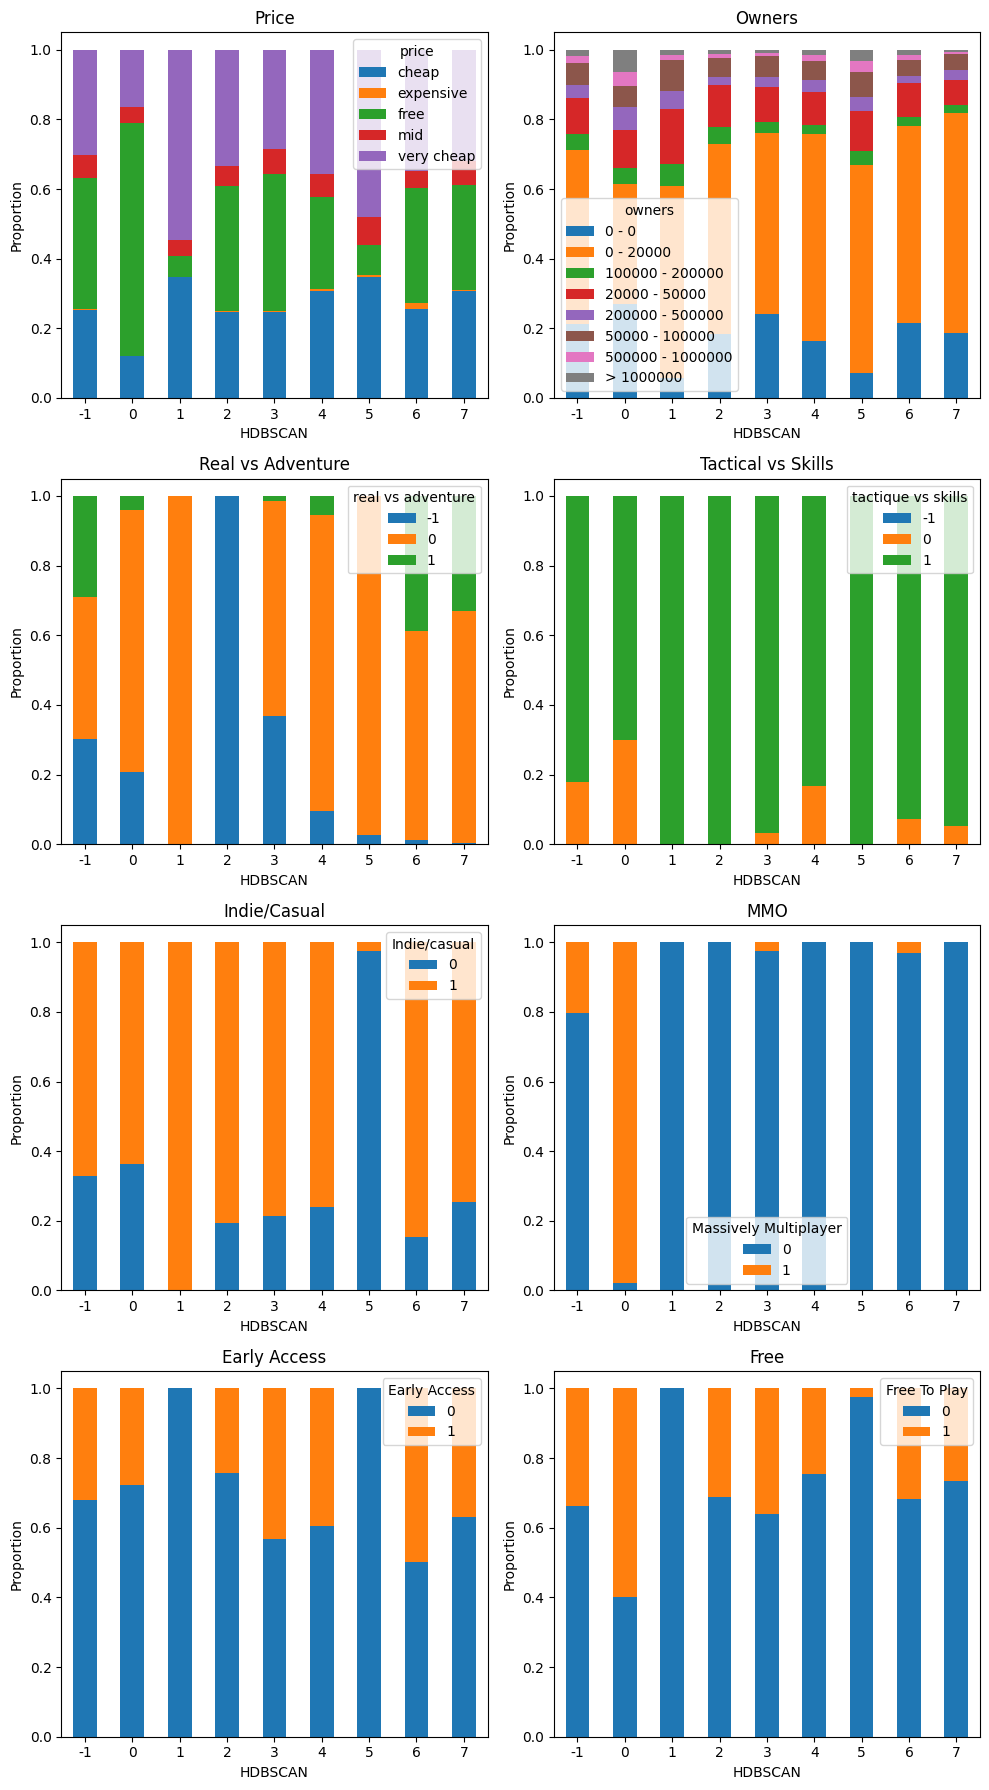

In [118]:
fig, axes = plt.subplots(4, 2, figsize=(10, 18))
axes = axes.flatten()
vars_to_plot = [
    ("price", "Price"),
    ("owners", "Owners"),
    ("real vs adventure", "Real vs Adventure"),
    ("tactique vs skills", "Tactical vs Skills"),
    ("Indie/casual", "Indie/Casual"),
    ("Massively Multiplayer", "MMO"),
    ("Early Access", "Early Access"),
    ("Free To Play","Free")
]
for i, (var, title) in enumerate(vars_to_plot):
    
    dist = (
        coord_niche
        .groupby("hdbscan")[var]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )
    
    dist.plot(kind="bar", stacked=True, ax=axes[i])
    
    axes[i].set_title(title)
    axes[i].set_xlabel("HDBSCAN")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Commentaires**
- Niche 0 :
    - MMO
    - Prix bas, bcp gratuit
    - nb de joueurs varié : bcp très connu (>500k), mais aussi bcp 0 joueurs
- Niche 1 :
    - Purement Indie, Casual
    - nombre de joueurs : moins de 0-0, bcp > 20k
    - Pas early access
    - Pas de jeux gratuit
- Niche 5 :
    - Purement Non Indie, Non Casual
    - nombre de joueurs : moins de 0-0, bcp > 20k
    - Pas early access
    - Pas de jeux gratuit 

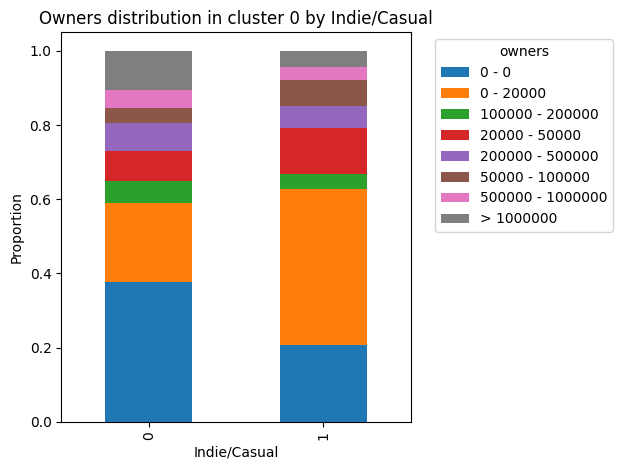

In [129]:
dist = (
    coord_niche[coord_niche["hdbscan"] == 0]   # filter cluster 0
    .groupby("Indie/casual")["owners"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

dist.plot(kind="bar", stacked=True)
plt.xlabel("Indie/Casual")
plt.ylabel("Proportion")
plt.title("Owners distribution in cluster 0 by Indie/Casual")
plt.legend(title="owners", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()